# Events definition and Analysis

This notebook defines the shock events and analyses the response of those shocks.

The structure of the notebook is as follows:
- Importing the parquet constructed from the previous notebook and add the shock events to create the events panel
- Filter the events panel to avoid overlap shocks
- Define the signed response and observe the statistics by relevant groups
- Create the audit table to observe date and time for the major shock events

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import parquet and create events panel

In [2]:
panel = pd.read_parquet("./outputs/parquets/research_panel.parquet")
panel.head()

,ticker,date_time,date,time,minute_of_day,close,ret,log_ret,bar_idx,ret_3b,vol_78b,z_shock_3b,ret_fwd_1b,ret_fwd_3b,ret_fwd_6b,ret_fwd_12b
0,DIA,2025-10-27 09:30:00,2025-10-27,09:30:00,570,474.68,NaN,NaN,0,NaN,NaN,NaN,-0.000717,NaN,NaN,NaN
1,DIA,2025-10-27 09:35:00,2025-10-27,09:35:00,575,474.34,-0.000716,-0.000717,1,NaN,NaN,NaN,-0.000401,NaN,NaN,NaN
2,DIA,2025-10-27 09:40:00,2025-10-27,09:40:00,580,474.15,-0.000401,-0.000401,2,NaN,NaN,NaN,-0.000169,-0.001286,NaN,NaN
3,DIA,2025-10-27 09:45:00,2025-10-27,09:45:00,585,474.07,-0.000169,-0.000169,3,-0.001286,NaN,NaN,0.000843,0.000274,NaN,NaN
4,DIA,2025-10-27 09:50:00,2025-10-27,09:50:00,590,474.47,0.000844,0.000843,4,0.000274,NaN,NaN,0.000443,0.001117,NaN,NaN


In [3]:
# make time of the day buckets to sort the shock events in
def add_time_of_day_bucket(event_df, minute_col="minute_of_day"):
    out = event_df.copy()

    # open: 9:30 ~ 10:30, midday: 10:30 ~ 12:30, afternoon: 12:30 ~ 15:00, close: 15:00 ~ 16:00
    bucket_conditions = [
        (out[minute_col] >= 570) & (out[minute_col] < 630),
        (out[minute_col] >= 630) & (out[minute_col] < 750),
        (out[minute_col] >= 750) & (out[minute_col] < 900),
        (out[minute_col] >= 900) & (out[minute_col] < 960),
    ]
    choices = ["open", "midday", "afternoon", "close"]

    out["tod_bucket"] = np.select(bucket_conditions, choices, default="outside_rth")
    return out

def make_shock_events_panel(
        panel,
        z_col="z_shock_3b",
        threshold=2.5,
        forward_cols=("ret_fwd_1b", "ret_fwd_3b", "ret_fwd_6b", "ret_fwd_12b")
        ):

        keep_cols = [
               "ticker",
               "date_time", "date", "time", "minute_of_day", "bar_idx",
                "ret_3b", "vol_78b", z_col, *forward_cols
                ]

        events = panel[keep_cols].copy()
        events = events.dropna(subset=[z_col, *forward_cols]).copy()

        # threshold event definition
        events = events.loc[events[z_col].abs() >= threshold].copy()

        # rename and add simple descriptors
        events = events.rename(columns={z_col: "z_shock"})
        events["abs_z_shock"] = events["z_shock"].abs()
        events["shock_sign"] = np.where(events["z_shock"] > 0, 1, -1)
        events["shock_side"] = np.where(events["z_shock"] > 0, "positive", "negative")

        events = add_time_of_day_bucket(events, minute_col="minute_of_day")
        events = events.sort_values(["ticker", "date_time"]).reset_index(drop=True)

        return events

In [4]:
# observe the panel for GLD ticker
events = make_shock_events_panel(panel)
events[events["ticker"] == "GLD"].head()

,ticker,date_time,date,time,minute_of_day,bar_idx,ret_3b,vol_78b,z_shock,ret_fwd_1b,ret_fwd_3b,ret_fwd_6b,ret_fwd_12b,abs_z_shock,shock_sign,shock_side,tod_bucket
96,GLD,2025-10-29 14:45:00,2025-10-29,14:45:00,885,63,-0.008515,0.001831,-2.685357,0.001264,0.000357,-0.006271,-0.009691,2.685357,-1,negative,afternoon
97,GLD,2025-10-31 12:05:00,2025-10-31,12:05:00,725,31,-0.005746,0.000915,-3.624701,-0.004891,-0.008419,-0.009853,-0.009452,3.624701,-1,negative,midday
98,GLD,2025-10-31 12:10:00,2025-10-31,12:10:00,730,32,-0.008419,0.001067,-4.555359,-0.000178,-0.006698,-0.009544,-0.009273,4.555359,-1,negative,midday
99,GLD,2025-10-31 12:15:00,2025-10-31,12:15:00,735,33,-0.006698,0.001067,-3.624693,0.001720,-0.003349,-0.009095,-0.007986,3.624693,-1,negative,midday
100,GLD,2025-11-06 12:20:00,2025-11-06,12:20:00,740,34,-0.004059,0.000844,-2.777817,0.000654,-0.002306,-0.002899,-0.003545,2.777817,-1,negative,midday


## Filter overlapping events

In [5]:
# add cooldown so quick successive spikes are counted as one event rather than multiple
def events_bar_filter(events, cooldown_bars=12, bar_col="bar_idx"):
    parts = []

    # observe events for each ticker-date
    for (ticker, date), g in events.groupby(["ticker", "date"], sort=False):
        g = g.sort_values("date_time").copy()

        keep = []
        last_kept_bar = -np.inf

        for b in g[bar_col].to_numpy():
            is_kept = (b - last_kept_bar) >= cooldown_bars
            keep.append(is_kept)
            parts.append(is_kept)
            if is_kept:
                last_kept_bar = b

    return parts

In [6]:
events_kept = events_bar_filter(events)
events_filtered = events.loc[events_kept].copy().reset_index(drop=True)
print(events.shape, events_filtered.shape)

(611, 17) (345, 17)


In [7]:
print(events_filtered["shock_sign"].value_counts() , "\n")
print(events_filtered["ticker"].value_counts())

shock_sign
-1    198
 1    147
Name: count, dtype: int64 

ticker
IWM    35
SPY    35
QQQ    34
GLD    32
LQD    31
DIA    30
IEF    29
HYG    28
TLT    26
EEM    23
XLF    22
XLE    20
Name: count, dtype: int64


In [8]:
# count how many events recorded and filtered
raw_counts = events["ticker"].value_counts().sort_index()
kept_counts = events_filtered["ticker"].value_counts().sort_index()

compare_counts = pd.DataFrame({
    "raw_events": raw_counts,
    "kept_events": kept_counts,
}).fillna(0)

compare_counts["dropped"] = compare_counts["raw_events"] - compare_counts["kept_events"]
compare_counts["keep_rate"] = compare_counts["kept_events"] / compare_counts["raw_events"]

compare_counts.sort_values("raw_events", ascending=False)

,raw_events,kept_events,dropped,keep_rate
ticker,,,,
GLD,65,32,33,0.492308
SPY,63,35,28,0.555556
IWM,60,35,25,0.583333
QQQ,59,34,25,0.576271
LQD,55,31,24,0.563636
IEF,50,29,21,0.580000
DIA,49,30,19,0.612245
EEM,47,23,24,0.489362
HYG,44,28,16,0.636364


## Reponse of shock events

In [9]:
# signed reponse of shock events, signed response = shock sign * cumulative forward returns
# positive -> continuation of shock, negative -> mean reversion of the shock
def response_stats(
    event_df,
    forward_cols=("ret_fwd_1b", "ret_fwd_3b", "ret_fwd_6b", "ret_fwd_12b"),
    group_col=None,
):
    df = event_df.copy()

    # maps bars to minutes
    horizon_b_to_min_map = {
        "ret_fwd_1b": 5,
        "ret_fwd_3b": 15,
        "ret_fwd_6b": 30,
        "ret_fwd_12b": 60,
    }

    rows = []

    if group_col is None:
        groups = [(None, df)]
    else:
        groups = df.groupby(group_col)

    # group by ticker, shock side, and etc.
    for group_value, g in groups:
        for fwd_col in forward_cols:
            # signed response
            signed = (g["shock_sign"] * g[fwd_col]).dropna()

            # relevant stats
            n = len(signed)
            mean = signed.mean()
            median = signed.median()
            std = signed.std(ddof=1) if n > 1 else np.nan
            se = std / np.sqrt(n) if n > 1 else np.nan

            row = {}

            if group_col is not None:
                row[group_col] = group_value

            row["horizon"] = fwd_col
            row["horizon_minutes"] = horizon_b_to_min_map[fwd_col]
            row["mean_signed_response"] = mean
            row["median_signed_response"] = median
            row["std_signed_response"] = std
            row["se_signed_response"] = se
            row["ci95_lo"] = mean - 1.96 * se if pd.notna(se) else np.nan
            row["ci95_hi"] = mean + 1.96 * se if pd.notna(se) else np.nan
            row["n_events"] = n

            rows.append(row)

    sort_cols = ([group_col] if group_col is not None else []) + ["horizon_minutes"]

    return pd.DataFrame(rows).sort_values(sort_cols).reset_index(drop=True)

In [10]:
events_stats = response_stats(events_filtered)
events_stats

,horizon,horizon_minutes,mean_signed_response,median_signed_response,std_signed_response,se_signed_response,ci95_lo,ci95_hi,n_events
0,ret_fwd_1b,5,0.000278,0.000117,0.001324,0.000071,0.000138,0.000418,345
1,ret_fwd_3b,15,0.003380,0.002445,0.003520,0.000190,0.003009,0.003752,345
2,ret_fwd_6b,30,0.004290,0.003229,0.004543,0.000245,0.003811,0.004770,345
3,ret_fwd_12b,60,0.004501,0.003245,0.005434,0.000293,0.003928,0.005075,345


In [11]:
# stats by shock side
signed_events_stats = response_stats(events_filtered, group_col="shock_side")
signed_events_stats

,shock_side,horizon,horizon_minutes,mean_signed_response,median_signed_response,std_signed_response,se_signed_response,ci95_lo,ci95_hi,n_events
0,negative,ret_fwd_1b,5,0.000212,0.000041,0.001351,0.000096,0.000024,0.000400,198
1,negative,ret_fwd_3b,15,0.003376,0.002500,0.003691,0.000262,0.002861,0.003890,198
2,negative,ret_fwd_6b,30,0.004429,0.003250,0.005133,0.000365,0.003714,0.005144,198
3,negative,ret_fwd_12b,60,0.005057,0.003784,0.006143,0.000437,0.004201,0.005912,198
4,positive,ret_fwd_1b,5,0.000367,0.000160,0.001287,0.000106,0.000159,0.000575,147
5,positive,ret_fwd_3b,15,0.003387,0.002344,0.003289,0.000271,0.002855,0.003919,147
6,positive,ret_fwd_6b,30,0.004103,0.003054,0.003608,0.000298,0.003520,0.004687,147
7,positive,ret_fwd_12b,60,0.003753,0.002734,0.004204,0.000347,0.003073,0.004433,147


In [12]:
# mean values of shock side
events_filtered.groupby("shock_side")[["ret_fwd_1b", "ret_fwd_3b", "ret_fwd_6b", "ret_fwd_12b"]].mean()

,ret_fwd_1b,ret_fwd_3b,ret_fwd_6b,ret_fwd_12b
shock_side,,,,
negative,-0.000212,-0.003376,-0.004429,-0.005057
positive,0.000367,0.003387,0.004103,0.003753


In [13]:
# stats by ticker
ticker_events_stats = response_stats(events_filtered, group_col="ticker")
ticker_events_stats

,ticker,horizon,horizon_minutes,mean_signed_response,median_signed_response,std_signed_response,se_signed_response,ci95_lo,ci95_hi,n_events
0,DIA,ret_fwd_1b,5,0.000270,0.000215,0.000986,0.000180,-0.000083,0.000623,30
1,DIA,ret_fwd_3b,15,0.003557,0.002977,0.002301,0.000420,0.002734,0.004380,30
2,DIA,ret_fwd_6b,30,0.004130,0.003300,0.002464,0.000450,0.003248,0.005012,30
3,DIA,ret_fwd_12b,60,0.003903,0.003775,0.003385,0.000618,0.002692,0.005115,30
4,EEM,ret_fwd_1b,5,0.000729,0.000634,0.001799,0.000375,-0.000006,0.001465,23
5,EEM,ret_fwd_3b,15,0.004459,0.003837,0.003985,0.000831,0.002831,0.006088,23
6,EEM,ret_fwd_6b,30,0.006334,0.005409,0.004152,0.000866,0.004637,0.008031,23
7,EEM,ret_fwd_12b,60,0.006616,0.005954,0.005570,0.001161,0.004340,0.008893,23
8,GLD,ret_fwd_1b,5,0.000731,0.000299,0.002479,0.000438,-0.000128,0.001590,32
9,GLD,ret_fwd_3b,15,0.006759,0.005105,0.006601,0.001167,0.004471,0.009046,32


In [14]:
# summarise more cleanly by mean signed response
ticker_pivot = ticker_events_stats.pivot(
    index="ticker",
    columns="horizon_minutes",
    values="mean_signed_response"
).sort_index()

ticker_pivot

horizon_minutes,5,15,30,60
ticker,,,,
DIA,0.000270,0.003557,0.004130,0.003903
EEM,0.000729,0.004459,0.006334,0.006616
GLD,0.000731,0.006759,0.009358,0.010305
HYG,0.000071,0.000885,0.001066,0.001087
IEF,0.000033,0.000921,0.001178,0.001266
IWM,0.000582,0.005198,0.006580,0.006169
LQD,0.000125,0.001130,0.001457,0.001625
QQQ,0.000352,0.004244,0.004977,0.005690
SPY,0.000213,0.003006,0.003710,0.004224


## Make audit events

In [15]:
# complie major shock events
def make_event_audit_table(event_df):
    cols = [
        "ticker",
        "date_time", "date",
        "shock_side", "z_shock", "abs_z_shock",
        "ret_3b", "ret_fwd_1b", "ret_fwd_3b", "ret_fwd_6b", "ret_fwd_12b",
        "bar_idx", "tod_bucket",
    ]
    out = event_df[cols].copy()
    out = out.sort_values(["abs_z_shock", "date_time"], ascending=[False, True]).reset_index(drop=True)
    return out

audit = make_event_audit_table(events_filtered)
audit.head(20)

,ticker,date_time,date,shock_side,z_shock,abs_z_shock,ret_3b,ret_fwd_1b,ret_fwd_3b,ret_fwd_6b,ret_fwd_12b,bar_idx,tod_bucket
0,GLD,2026-01-16 10:25:00,2026-01-16,negative,-6.808242,6.808242,-0.011148,-0.004561,-0.012535,-0.015462,-0.013630,11,open
1,GLD,2026-02-12 11:10:00,2026-02-12,negative,-5.045494,5.045494,-0.021874,-0.003402,-0.026243,-0.027982,-0.026329,20,midday
2,IWM,2025-12-10 14:05:00,2025-12-10,positive,4.850109,4.850109,0.007998,-0.000454,0.007425,0.006789,0.004567,55,afternoon
3,GLD,2026-01-29 10:25:00,2026-01-29,negative,-4.806954,4.806954,-0.036825,-0.005087,-0.031736,-0.055448,-0.066802,11,open
4,EEM,2025-12-12 10:25:00,2025-12-12,negative,-4.241262,4.241262,-0.004489,0.000184,-0.003574,-0.005950,-0.008138,11,open
5,QQQ,2026-03-05 10:25:00,2026-03-05,negative,-4.201002,4.201002,-0.006598,-0.001440,-0.005273,-0.007785,-0.004667,11,open
6,LQD,2025-11-28 10:35:00,2025-11-28,negative,-4.174415,4.174415,-0.001520,0.000134,-0.001207,-0.001431,-0.002369,13,midday
7,EEM,2025-11-06 10:35:00,2025-11-06,negative,-4.107784,4.107784,-0.005106,-0.001097,-0.005384,-0.003380,-0.007476,13,midday
8,IEF,2026-01-16 10:40:00,2026-01-16,negative,-4.104969,4.104969,-0.001300,-0.000365,-0.001562,-0.001874,-0.001678,14,midday
9,SPY,2025-12-10 14:05:00,2025-12-10,positive,4.086360,4.086360,0.003655,-0.000788,0.002749,0.003006,0.001344,55,afternoon


In [16]:
# check time of the day bucket
events_filtered.groupby("tod_bucket").size().sort_values(ascending=False)

tod_bucket
midday       174
afternoon    110
close         32
open          29
dtype: int64

In [17]:
# check the exact time, note: there is a 15 minute lag from the 3-bar return
events_filtered["clock_time"] = pd.to_datetime(events["date_time"]).dt.strftime("%H:%M")
events_filtered.groupby("clock_time").size().sort_values(ascending=False).head(10)

clock_time
10:35    22
10:40    20
11:05    17
10:25    15
11:10    14
11:15    13
14:35    13
10:45    12
11:20    11
11:00    10
dtype: int64

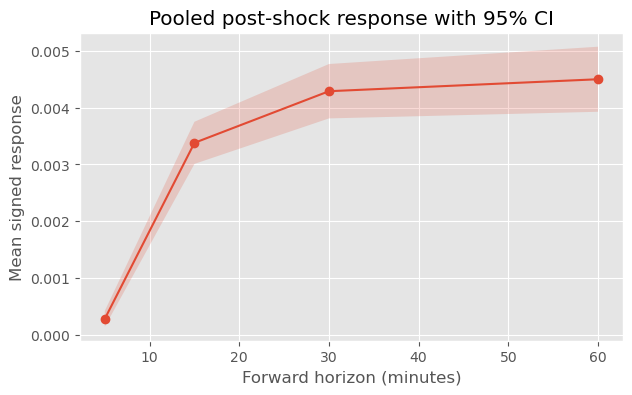

In [18]:
# plot the shock response
plot_df = events_stats.copy()

plt.style.use('ggplot')
plt.figure(figsize=(7, 4))
plt.plot(plot_df["horizon_minutes"], plot_df["mean_signed_response"], marker="o")
plt.fill_between(
    plot_df["horizon_minutes"],
    plot_df["ci95_lo"],
    plot_df["ci95_hi"],
    alpha=0.2,
)

plt.xlabel("Forward horizon (minutes)")
plt.ylabel("Mean signed response")
plt.title("Pooled post-shock response with 95% CI")
plt.show()